In [1]:
"""
Created on Tue Feb 11 15:09:59 2025

@author: hartvig
"""

import plotly.express as px
import pandas as pd
import os
import plotly.io as pio
import geopandas as gpd
import shapely
import numpy as np
import matplotlib as plt



In [2]:
# Load output files
years = list(range(2024, 2041))
iters = 5
baseline = 'baseline_wo_l'
year_col = years * iters
iter_col = pd.Series(np.repeat(list(range(iters)), len(years)))
index = pd.MultiIndex.from_arrays([iter_col, year_col], names=("Iteration", "Year"))

scen_names = ['baseline_wo_l', 'baseline_w_il', 'baseline_w_pl', 'innerestadt_wo_l', 'innerestadt_w_il', 'innerestadt_w_pl', 
              'allcity_wo_l', 'allcity_w_il', 'allcity_w_pl', 'zoning_wo_l', 'zoning_w_il', 'zoning_w_pl']
scen_names = ['baseline_wo_l', 'baseline_w_il', 'baseline_w_pl', 'innerestadt_wo_l', 'innerestadt_w_il', 'innerestadt_w_pl']
modes = ['Bicycle', 'Walk', 'Car', 'PT']
dists = [1010, 1020, 1030, 1040, 1050, 1060, 1070, 1080, 1090, 1100, 1110, 1120, 1130, 1140, 1150, 1160, 
         1170, 1180, 1190, 1200, 1210, 1220, 1230]
scens = {}
scens['files'] = {}
scens['data'] = {}
for scen in scen_names:
    scens['files'][scen] = {}
    scens['data'][scen] = {}
    files = [f for f in os.listdir('output/results') if scen in f]
    scens['files'][scen] = files
    for f in files:
        fn = "output/results/" + f 
        iter_nr = int(f.split("_")[-2].replace("iter", ""))
        year = int(f.split("_")[-1].split(".")[0])
        read = pd.read_csv(fn, index_col = 0)
        read.index = (read.index + 100) * 10
        read = read.reindex(dists)
        read = read.fillna(0)
        for col in read.columns:
            if col not in scens['data'][scen].keys():
                scens['data'][scen][col] = pd.DataFrame(0.0, columns = dists, index = index)
            scens['data'][scen][col].loc[(iter_nr, year), :] = read[col].values


In [3]:
scens['data']['innerestadt_w_il'].keys()

dict_keys(['Bicycle', 'Walk', 'Car', 'PT', 'PBC', 'PN', 'KN', 'guilt', 'mot', 'cons', 'district_pop', 'total_trips'])

In [4]:
# Calculate relative and absolute diff from baseline
scens['rel_chng'] = {}
scens['abs_chng'] = {}
for scen in scen_names:
    scens['rel_chng'][scen] = {}
    scens['abs_chng'][scen] = {}

    for col in scens['data'][baseline].keys():
        if scen != baseline:
            scens['rel_chng'][scen][col] = ((scens['data'][scen][col] / scens['data'][baseline][col] - 1) * 100).fillna(0) 
            scens['abs_chng'][scen][col] = scens['data'][scen][col] - scens['data'][baseline][col]

# Calculate modal shares
scens['modal_shares'] = {}
for scen in scen_names:
    scens['modal_shares'][scen] = pd.DataFrame(0.0, columns = modes, index = index)
    for mode in modes:
        scens['modal_shares'][scen][mode] = ((scens['data'][scen][mode] * scens['data'][scen]['district_pop']).sum(axis = 1) 
                                             / (scens['data'][scen]['total_trips'].sum(axis = 1)))

In [5]:
for scen in scen_names:
    print(scen)
    print(round(scens['modal_shares'][scen]['Bicycle'].xs(2040, level="Year").mean() * 100, 1))

baseline_wo_l
12.8
baseline_w_il
19.5
baseline_w_pl
19.0
innerestadt_wo_l
15.1
innerestadt_w_il
28.6
innerestadt_w_pl
34.5


In [6]:
round(scens['modal_shares']['baseline_wo_l'].groupby(level=1).mean() * 100, 1)

,Bicycle,Walk,Car,PT
Year,,,,
2024,10.1,32.0,25.3,32.5
2025,10.5,32.4,25.1,32.0
2026,10.7,32.6,24.9,31.8
2027,11.0,32.7,24.8,31.5
2028,11.2,32.9,24.6,31.3
2029,11.4,33.0,24.6,31.1
2030,11.5,33.1,24.4,30.9
2031,11.7,33.2,24.3,30.7
2032,11.8,33.4,24.2,30.6


In [8]:
# Plot Vienna map with area definitions
import geopandas as gpd
import matplotlib.pyplot as plt
plt.rcParams.update({
    'font.size': 9  # Change this value as needed (e.g., 10, 14, etc.)
})
vienna_bike_map = gpd.read_file('data/RADWEGEOGD//RADWEGEOGDLine.shp')
vienna_bike_map = vienna_bike_map.loc[vienna_bike_map.MERKMAL.isin(['Getrennte Führung', 'Radroute'])]
vienna_district_map = gpd.read_file('data/ZAEHLBEZIRKOGD//ZAEHLBEZIRKOGDPolygon.shp')

In [9]:
scen_names

['baseline_wo_l',
 'baseline_w_il',
 'baseline_w_pl',
 'innerestadt_wo_l',
 'innerestadt_w_il',
 'innerestadt_w_pl']

In [66]:
plot_map['Absolute change'].min()

1.2015702139145692

--------------------------------------------
innerestadt_w_il
--------------------------------------------


<Figure size 640x5000 with 0 Axes>

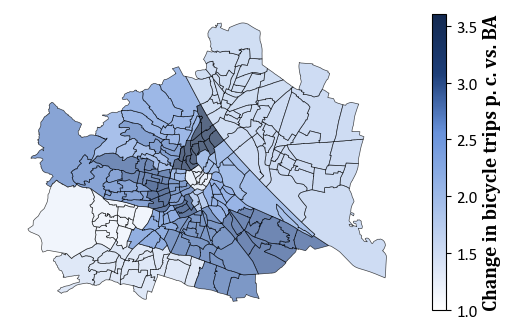

In [67]:
from matplotlib.colors import Normalize
from matplotlib.colors import ListedColormap
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams["font.family"] = "Calibri"
plt.rcParams["font.size"] = 12
mode = 'Bicycle'
# for scen in scen_names:

# Define your color list
# Red
colors = ["#FFFFFF", "#F8C3C4", "#F5A5A6", "#E51C1F", "#9A1114"]
# Yellow
# colors = ["#FFFFFF", "#FDE4B3", "#FDD68C", "#E79A05", "#9A6703"]
# Blue
colors = ["#FFFFFF", "#CDDBF3", "#9AB7E7", "#6892DB", "#1D3E78", "#132950"]

# Create the colormap
custom_cmap = ListedColormap(colors, name="custom_redscale")
custom_cmap = LinearSegmentedColormap.from_list("custom_redscale", colors, N=256)


for scen in ['innerestadt_w_il']:

    print('--------------------------------------------')
    print(scen)
    print('--------------------------------------------')

    if scen != baseline:
        for year in [2040]:
            plot_map = vienna_district_map.copy()
            rel_change = scens['abs_chng'][scen][mode].copy()
            rel_change = rel_change.xs(year, level = 'Year').mean()
            rel_change.name = 'Absolute change'
            plot_map['BEZIRK'] = plot_map.BEZNR * 10 + 1000
            plot_map['BEZIRK'] = plot_map['BEZIRK'].astype(int)
            plot_map = plot_map.join(rel_change, on = "BEZIRK")
        
            plt.figure().set_figheight(50)
            # Define normalization: everything above 50 will have the same max color
            # norm = Normalize(vmin=0, vmax=50)
            # Blues - Integrated
            ax = plot_map.plot(column="Absolute change", edgecolor="black", linewidth = 0.5, alpha = 0.7, cmap=custom_cmap, 
                                          vmin=1, vmax=3.6, legend=False, legend_kwds={"label": "Change in bicycle trips p. c. vs. BA", "shrink": 0.8})
            
            # Place colorbar below the map
            sm = plt.cm.ScalarMappable(cmap=custom_cmap)
            sm.set_array(plot_map["Absolute change"])  # don't normalize
            cbar = plt.colorbar(sm, ax=ax, orientation='vertical', pad=0.05, shrink=0.8)
            # Set label with custom font
            sm.set_clim(1, 3.6)  # set the same limits as your plot
            cbar.set_label(
                "Change in bicycle trips p. c. vs. BA",
                fontname="Cambria",  # font family
                fontsize=14,         # font size
                fontweight='bold'    # weight
            )

            
            ax.set_xticks([16.2, 16.3, 16.4, 16.5, 16.6])
            # ax.set_title(scen, fontsize=20, fontname="Cambria")

            # Change the border (spine) color and thickness
            for spine in ax.spines.values():
                spine.set_edgecolor('navy')   # border color
                spine.set_linewidth(2)         # border thickness
                spine.set_visible(False)

            # We can now plot our ``GeoDataFrame``.
            # color_scale = [(0, 'blue'), (1,'black')]
            # plot_map.plot(ax=ax, color = 'purple', linewidth = 0.25, alpha = 0.8)
            # plt.xlabel("Longitude")
            # plt.ylabel("Latitude")
            plt.gca().axes.get_xaxis().set_visible(False)  # hides the whole x-axis
            plt.gca().axes.get_yaxis().set_visible(False)  # hides the whole x-axis

            plt.show()
            ax.figure.savefig('figures/' + scen + '_' + mode + '_vienna_map_' + str(year) + '.png', bbox_inches="tight", pad_inches=0.1, dpi = 700)

--------------------------------------------
baseline_wo_l
--------------------------------------------


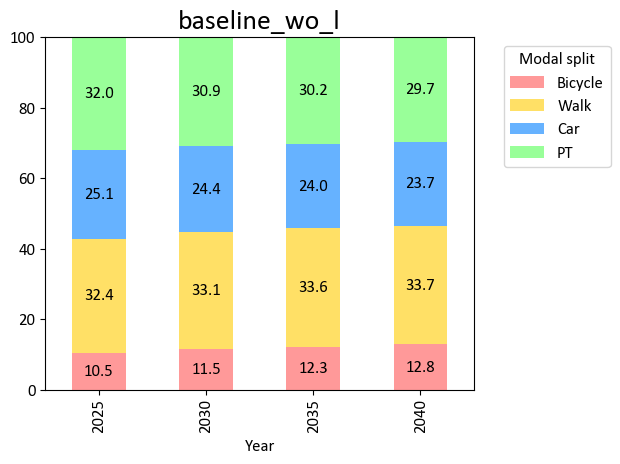

--------------------------------------------
baseline_w_il_radius30_wo_l
--------------------------------------------


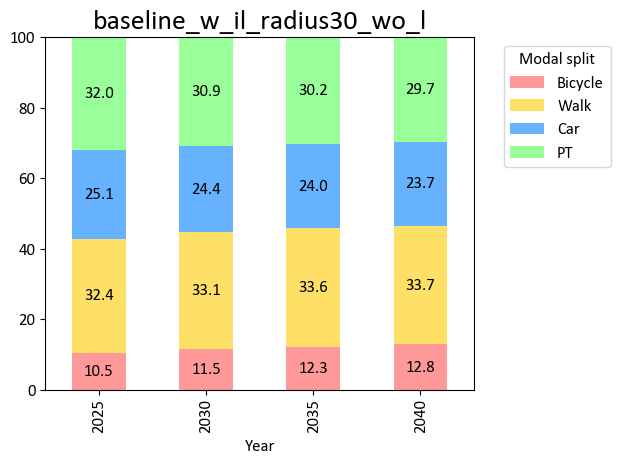

--------------------------------------------
baseline_w_il_radius30_w_il
--------------------------------------------


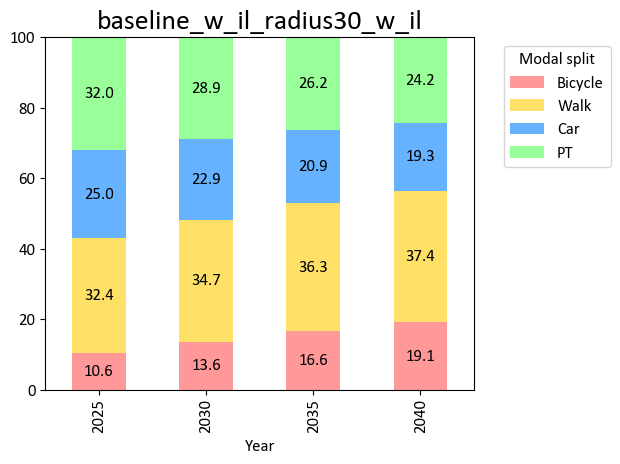

--------------------------------------------
baseline_w_il_radius30_w_pl
--------------------------------------------


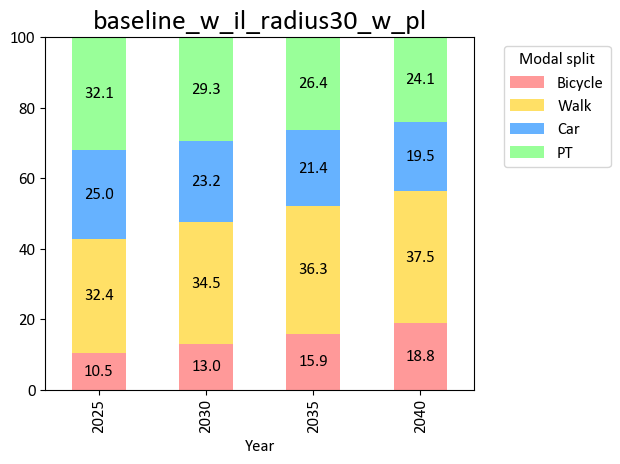

In [17]:
from matplotlib.colors import Normalize
plt.rcParams["font.family"] = "Calibri"
plt.rcParams["font.size"] = 12
# Custom color palette (4 colors)
colors = ["#FF9999", "#FFE066", "#66B2FF", "#99FF99"]
mode = 'Bicycle'
for scen in scen_names:
    print('--------------------------------------------')
    print(scen)
    print('--------------------------------------------')
    plot_df = scens['modal_shares'][scen]

    plot_df = plot_df.groupby(level="Year").mean() * 100
    # plt.figure().set_figheight(30)
    # Define normalization: everything above 50 will have the same max color
    # norm = Normalize(vmin=0, vmax=50)
    
    ax = plot_df.loc[[2025, 2030, 2035, 2040]].plot(column="Modal split", kind="bar", stacked=True, color=colors)
    ax.set_ylim(0, 100)
    # ax.set_xticks([16.2, 16.3, 16.4, 16.5, 16.6])
    ax.set_title(scen, fontsize=20, fontname="Calibri")
    # Add labels
    for c in ax.containers:  
        ax.bar_label(c, label_type="center", fmt="%.1f")  # 'center', 'edge', or 'inside'

    # Move legend outside
    ax.legend(title="Modal split", bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()  # adjusts plot to make room for legend
    plt.show()
    ax.figure.savefig('figures/' + scen + '_modal_split.png', bbox_inches="tight", pad_inches=0.1, dpi = 500)

In [71]:
scens['data'][scen].keys()


dict_keys(['Bicycle', 'Walk', 'Car', 'PT', 'PBC', 'PN', 'KN', 'guilt', 'mot', 'cons', 'district_pop', 'total_trips'])

--------------------------------------------
baseline_wo_l
--------------------------------------------


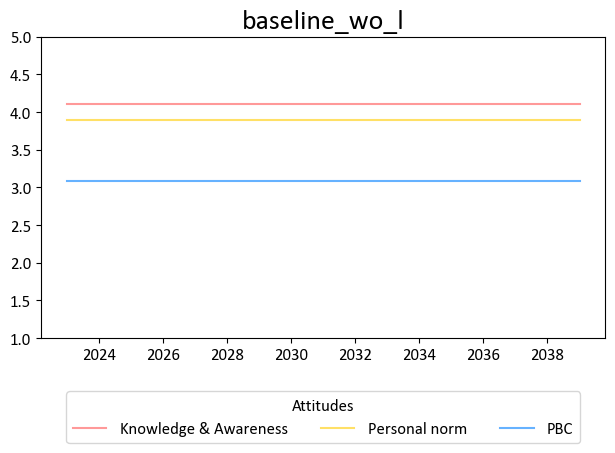

--------------------------------------------
baseline_w_il
--------------------------------------------


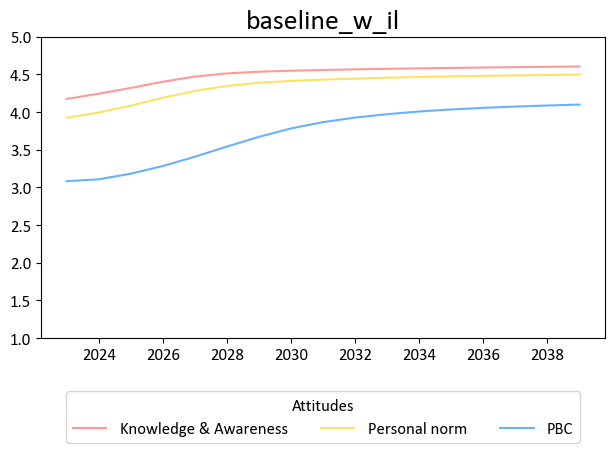

--------------------------------------------
baseline_w_pl
--------------------------------------------


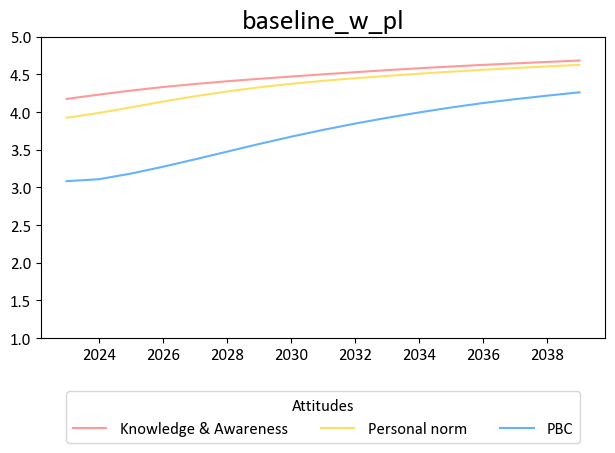

--------------------------------------------
innerestadt_wo_l
--------------------------------------------


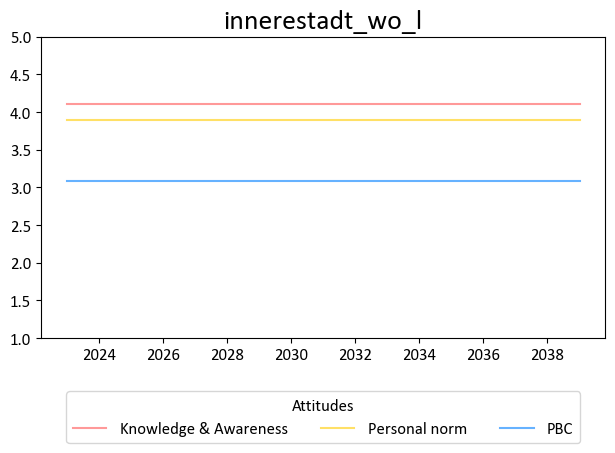

--------------------------------------------
innerestadt_w_il
--------------------------------------------


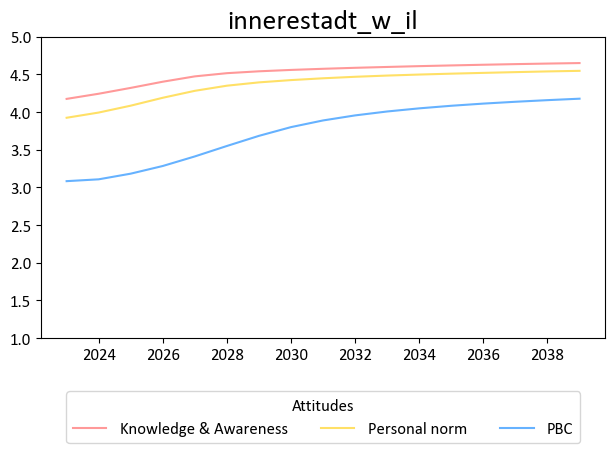

--------------------------------------------
innerestadt_w_pl
--------------------------------------------


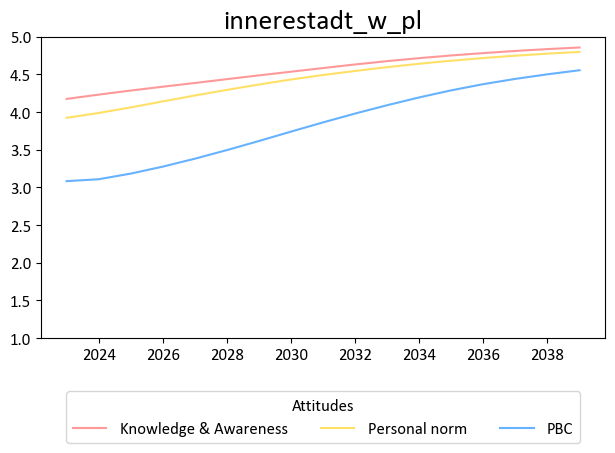

--------------------------------------------
allcity_wo_l
--------------------------------------------


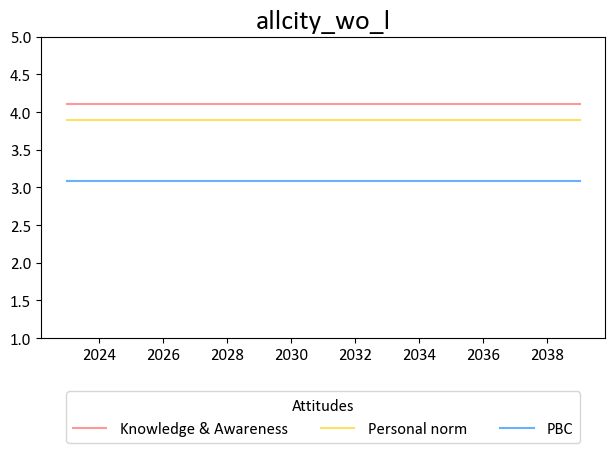

--------------------------------------------
allcity_w_il
--------------------------------------------


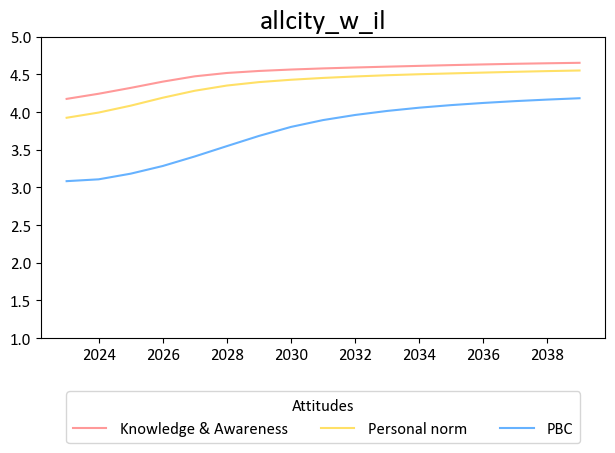

--------------------------------------------
allcity_w_pl
--------------------------------------------


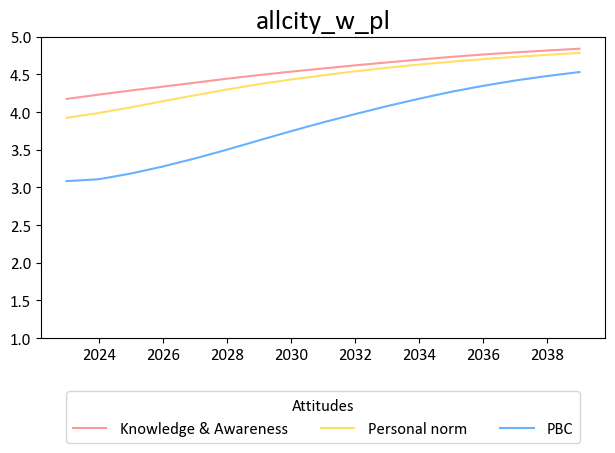

--------------------------------------------
zoning_wo_l
--------------------------------------------


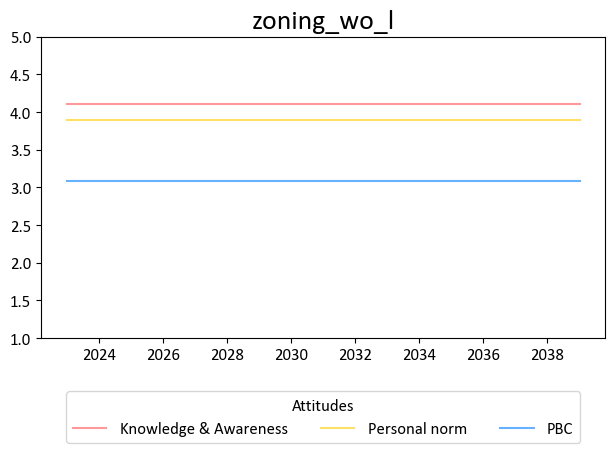

--------------------------------------------
zoning_w_il
--------------------------------------------


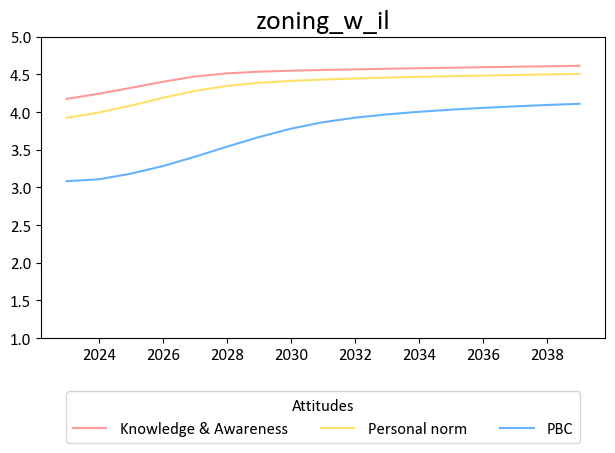

--------------------------------------------
zoning_w_pl
--------------------------------------------


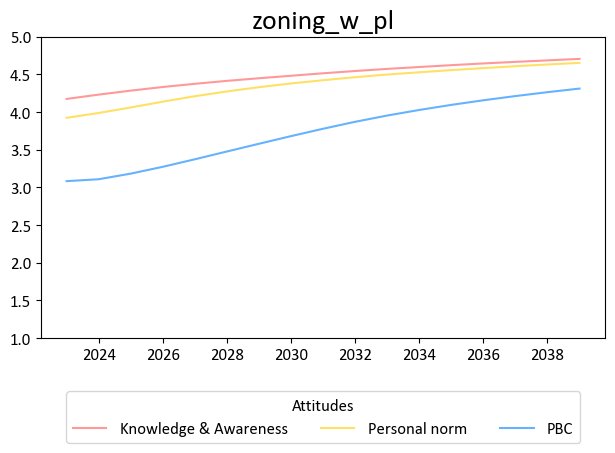

In [93]:
from matplotlib.colors import Normalize
plt.rcParams["font.family"] = "Calibri"
plt.rcParams["font.size"] = 12
colors = ["#FF9999", "#FFE066", "#66B2FF", "#99FF99"]

for scen in scen_names:
    # scen = 'baseline_wo_l'
    print('--------------------------------------------')
    print(scen)
    print('--------------------------------------------')
    plot_df = pd.DataFrame(0.0, columns = ['KN', 'PN', 'PBC'], index = range(2023, 2040))
    distr_pop = scens['data'][scen]['district_pop']
    distr_pop = distr_pop.groupby(level="Year").mean()
    tot_pop = distr_pop.loc[2023].sum()
    for attr in ['KN', 'PN', 'PBC']:
        attr_df = scens['data'][scen][attr].copy()
        attr_df = attr_df.groupby(level="Year").mean() * distr_pop
        attr_df = attr_df.sum(axis = 1) / tot_pop
        plot_df[attr] = attr_df

    plot_df = plot_df.rename(columns = {'KN': 'Knowledge & Awareness', 'PN': 'Personal norm', 'PBC': 'PBC'})
    ax = plot_df.plot(column="Agent attitudes", color=colors)
    ax.set_ylim(1, 5)
    ax.set_title(scen, fontsize=20, fontname="Calibri")

    # # We can now plot our ``GeoDataFrame``.
    # # color_scale = [(0, 'blue'), (1,'black')]
    # # plot_map.plot(ax=ax, color = 'purple', linewidth = 0.25, alpha = 0.8)
    # # plt.xlabel("Z")
    # # plt.ylabel("Latitude")
    # Move legend outside
    ax.legend(
            title="Attitudes",
            bbox_to_anchor=(0.5, -0.15),   # center bottom
            loc="upper center",
            ncol=4                         # put all 4 categories in one row
        )
    plt.tight_layout()  # adjusts plot to make room for legend
    plt.show()
    ax.figure.savefig('figures/' + scen + '_attitude.png', bbox_inches="tight", pad_inches=0.1, dpi = 500)

In [40]:
survey_distr = pd.read_csv('data/survey_district_distribution.csv', index_col = 0)['District']
vienna_district_map = vienna_district_map.join(survey_distr, on = "BEZNR")

<Figure size 640x3000 with 0 Axes>

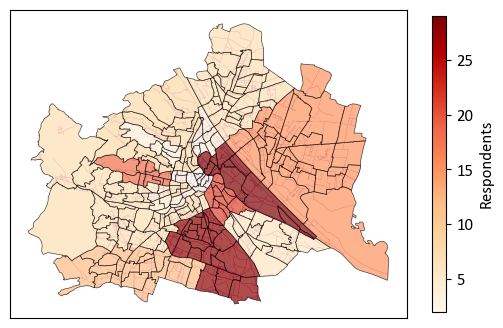

In [41]:
plt.figure().set_figheight(30)
ax = vienna_district_map.plot(column="District", edgecolor="black", linewidth = 0.5, alpha = 0.7, cmap='OrRd', 
                              legend=True, legend_kwds={"label": "Respondents", "shrink": 0.8})
ax.set_xticks([])
ax.set_yticks([])
ax.figure.set_facecolor("none")
# We can now plot our ``GeoDataFrame``.
color_scale = [(0, 'blue'), (1,'black')]
vienna_bike_map.plot(ax=ax, color = 'purple', linewidth = 0.25, alpha = 0.8, zorder=0)

plt.show()
ax.figure.savefig('survey_district_distribution_map.png', dpi = 1000)

In [79]:
for mode in modes:
    modal_shares = pd.DataFrame(0.0, index = years, columns = scen_names)
    for scen in scen_names:
        modal_shares[scen] = scens['modal_shares'][scen][mode].groupby(level=1).mean()
    modal_shares.loc[[2025, 2030, 2040]].to_csv('output/' + mode + '_modal_shares.csv', index = True)

In [22]:
scens['attr'] = {}

for scen in scen_names:
    scens['attr'][scen] = pd.DataFrame(0.0, index = index, columns = ['Knowledge & Awareness', 'Personal norm', 'PBC'])
    for year in years:
        files = [f for f in os.listdir('output') if ("attributes" in f) & ("_" + scen + "_" in f) & (str(year) in f)]
        for f in files:
            fn = "output/" + f 
            iter_nr = int(f.split("scen")[0].split("_")[1])
            read = pd.read_csv(fn)
            scens['attr'][scen].loc[(iter_nr, year), :] = read.values[:, 0]
    avg_attr = scens['attr'][scen].groupby(level=1).mean()
    avg_attr.to_csv('output/' + scen + '_attributes.csv', index = True)

In [20]:
avg_attr = scens['attr'][scen].groupby(level=1).mean()


In [21]:
avg_attr

,Knowledge & Awareness,Personal norm,PBC
Year,,,
2024,4.078878,3.936086,2.988151
2025,4.192834,4.044034,3.124300
2026,4.252151,4.118934,3.185185
2027,4.316119,4.207727,3.266943
2028,4.370286,4.291300,3.367990
2029,4.404694,4.356170,3.475209
2030,4.483657,4.481645,3.754172
2031,4.493993,4.509858,3.852527
2032,4.501715,4.531199,3.919576


In [20]:
scens['gender_male'] = {}
scens['gender_female'] = {}

for scen in scen_names:
    scens['gender_male'][scen] = pd.DataFrame(0.0, index = index, columns = modes)
    scens['gender_female'][scen] = pd.DataFrame(0.0, index = index, columns = modes)

    for year in years:
        files = [f for f in os.listdir('output') if ("gender" in f) & ("_" + scen + "_" in f) & (str(year) in f)]
        for f in files:
            fn = "output/" + f 
            iter_nr = int(f.split("scen")[0].split("_")[1])
            mode = f.split("_")[3]
            read = pd.read_csv(fn, index_col = 0)
            scens['gender_male'][scen].loc[(iter_nr, year), mode] = read.loc[0, mode]
            scens['gender_female'][scen].loc[(iter_nr, year), mode] = read.loc[1, mode]

    avg_male = scens['gender_male'][scen].groupby(level=1).mean()
    avg_female = scens['gender_female'][scen].groupby(level=1).mean()
    avg_gender = pd.merge(avg_female, avg_male, on = 'Year', suffixes=('_female', '_male'))
    avg_gender.to_csv('output/' + scen + '_gender.csv', index = True)

In [29]:
scens['age'] = {}
age_cats = ['18-24', '25-34', '35-44', '45-54', '55-64', '65-70', '71 and above']

for scen in scen_names:
    scens['age'][scen] = pd.DataFrame(0.0, index = index, columns = age_cats).groupby(level=1).mean()
    for mode in modes:
        mode_df = pd.DataFrame(0.0, index = index, columns = age_cats)

        for year in years:
            files = [f for f in os.listdir('output') if ("age" in f) & (mode in f) & ("_" + scen + "_" in f) & (str(year) in f)]
            for f in files:
                fn = "output/" + f 
                iter_nr = int(f.split("scen")[0].split("_")[1])
                read = pd.read_csv(fn, index_col = 0)
                mode_df.loc[(iter_nr, year), :] = read[mode]
                
        scens['age'][scen] = pd.merge(scens['age'][scen], mode_df.groupby(level=1).mean(), on = 'Year', suffixes=('', mode))
    scens['age'][scen].to_csv('output/' + scen + '_age.csv', index = True)